In [ ]:
# =========================
# SimCLR Model Definition
# =========================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# 1) Time-Shift Augmentation
def time_shift_augment(x, max_shift_fraction=0.1):
    batch_size, time_steps, _ = x.shape
    max_shift = int(max_shift_fraction * time_steps)
    if max_shift <= 0:
        return x
    x_aug = torch.empty_like(x)
    for i in range(batch_size):
        shift = torch.randint(-max_shift, max_shift+1, (1,), device=x.device).item()
        x_aug[i] = torch.roll(x[i], shifts=shift, dims=0)
    return x_aug

# 2) Encoder: 1D CNN + LSTM
class CNNLSTMEncoder(nn.Module):
    def __init__(self, input_dim=2, cnn_channels=64, lstm_hidden=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, cnn_channels, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU()
        )
        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.output_dim = lstm_hidden * 2

    def forward(self, x):
        x = x.permute(0, 2, 1)        # (B, C=2, T)
        x = self.conv(x)               # (B, Cc, T')
        x = x.permute(0, 2, 1)        # (B, T', Cc)
        lstm_out, _ = self.lstm(x)    # (B, T', 2H)
        features = torch.mean(lstm_out, dim=1)  # global avg pool over time
        return features

# 3) Projection Head
class ProjectionHead(nn.Module):
    def __init__(self, input_dim, proj_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, proj_dim)
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

# 4) SimCLR wrapper
class SimCLR(nn.Module):
    def __init__(self, input_dim=2, cnn_channels=64, lstm_hidden=128, proj_dim=128):
        super().__init__()
        self.encoder = CNNLSTMEncoder(input_dim, cnn_channels, lstm_hidden)
        self.projection = ProjectionHead(self.encoder.output_dim, proj_dim)
    def forward(self, x):
        features = self.encoder(x)
        z = self.projection(features)
        return z

# 5) InfoNCE loss
def info_nce_loss(z1, z2, temperature=0.07):
    z1, z2 = F.normalize(z1, dim=1), F.normalize(z2, dim=1)
    B = z1.size(0)
    reps = torch.cat([z1, z2], dim=0)                                 # (2B, D)
    sim = F.cosine_similarity(reps.unsqueeze(1), reps.unsqueeze(0), dim=2)  # (2B, 2B)
    mask = torch.eye(2*B, device=z1.device, dtype=torch.bool)
    sim = sim.masked_fill(mask, -9e15)
    pos = torch.cat([torch.diag(sim, B), torch.diag(sim, -B)], dim=0) # (2B,)
    numerator = torch.exp(pos / temperature)
    denominator = torch.sum(torch.exp(sim / temperature), dim=1)
    loss = -torch.log(numerator / denominator).mean()
    return loss

# 6) One training step
def training_step(model, x_batch, optimizer):
    x1 = time_shift_augment(x_batch)
    x2 = time_shift_augment(x_batch)
    z1 = model(x1)
    z2 = model(x2)
    loss = info_nce_loss(z1, z2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

# 7) Training loop (fixed to accept tensors from DataLoader)
def train_simclr_fixed(model, dataloader, epochs=10, lr=1e-3, device="cuda"):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        total_loss, n = 0.0, 0
        for x_batch in dataloader:
            x_batch = x_batch.to(device)        # (B, L, 2)
            loss = training_step(model, x_batch, optimizer)
            total_loss += loss; n += 1
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/max(1,n):.4f}")


In [ ]:
# =========================
# Colab + Data Preparation
# =========================
from google.colab import drive
drive.mount('/content/drive')

# Your files
clearsky_path = "/content/drive/MyDrive/clearsky_signal_C-1_trimmed.bin"
galileo_path  = "/content/drive/MyDrive/Galileo_3_Spoofer_Static_NoMP_TruePosition_trimmed.bin"

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

def load_iq_from_bin(path, fmt='int16', normalize=True, remove_dc=True, little_endian=True):
    """
    Load interleaved I/Q data and return float32 array of shape (T, 2).
    Supported fmt: 'int16' (interleaved), 'float32' (interleaved), 'complex64' (complex).
    """
    if fmt == 'int16':
        dt = np.dtype('<i2') if little_endian else np.dtype('>i2')
        raw = np.fromfile(path, dtype=dt)
        assert raw.size % 2 == 0, "int16 interleaved I/Q should have even length."
        iq = raw.reshape(-1, 2).astype(np.float32) / 32768.0  # scale to [-1, 1)
    elif fmt == 'float32':
        raw = np.fromfile(path, dtype=np.float32)
        assert raw.size % 2 == 0
        iq = raw.reshape(-1, 2).astype(np.float32)
    elif fmt == 'complex64':
        cplx = np.fromfile(path, dtype=np.complex64)
        iq = np.stack([cplx.real, cplx.imag], axis=1).astype(np.float32)
    else:
        raise ValueError("fmt must be 'int16', 'float32', or 'complex64'.")

    if remove_dc:
        iq -= np.mean(iq, axis=0, keepdims=True)

    if normalize:
        # robust per-file scaling
        s = np.maximum(1e-8, np.percentile(np.abs(iq), 95))
        iq = iq / s

    return iq

iq1 = load_iq_from_bin(clearsky_path, fmt='int16', normalize=True, remove_dc=True, little_endian=True)
iq2 = load_iq_from_bin(galileo_path,  fmt='int16', normalize=True, remove_dc=True, little_endian=True)

iq_all = np.concatenate([iq1, iq2], axis=0).astype(np.float32)  # (T, 2)
print("Total complex samples (I/Q pairs):", iq_all.shape[0])

class GNSSBinDataset(Dataset):
    """
    Emits windows of shape (L, 2) as torch.float32. Overlap set by stride.
    """
    def __init__(self, iq_array, window_len=4096, stride=2048, per_window_standardize=False):
        self.iq = iq_array
        self.L = int(window_len)
        self.S = int(stride)
        self.pw = per_window_standardize
        total = iq_array.shape[0]
        self.N = max(0, 1 + (total - self.L) // self.S)

    def __len__(self): return self.N

    def __getitem__(self, idx):
        s = idx * self.S
        e = s + self.L
        x = self.iq[s:e]
        if self.pw:
            m = np.mean(x, axis=0, keepdims=True)
            x = x - m
            s95 = np.maximum(1e-8, np.percentile(np.abs(x), 95))
            x = x / s95
        return torch.from_numpy(x.astype(np.float32))  # (L, 2)

# Windowing + DataLoader
WINDOW, STRIDE = 4096, 2048    # adjust to sampling rate if needed
BATCH_SIZE = 128
dataset = GNSSBinDataset(iq_all, window_len=WINDOW, stride=STRIDE, per_window_standardize=False)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)

print("Num windows:", len(dataset))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total complex samples (I/Q pairs): 26214400
Num windows: 12799


In [ ]:
# =========================
# Train
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = SimCLR(input_dim=2, cnn_channels=64, lstm_hidden=128, proj_dim=128)

EPOCHS = 10
LR = 1e-3

train_simclr_fixed(model, loader, epochs=EPOCHS, lr=LR, device=device)


Epoch [1/10] Loss: 1.8386
Epoch [2/10] Loss: 0.1937
Epoch [3/10] Loss: 0.0716
Epoch [4/10] Loss: 0.0341
Epoch [5/10] Loss: 0.0205
Epoch [6/10] Loss: 0.0182
Epoch [7/10] Loss: 0.0136
Epoch [8/10] Loss: 0.0114
Epoch [9/10] Loss: 0.0086
Epoch [10/10] Loss: 0.0078


In [ ]:
# =========================
# 1) Labeled window dataset
# =========================
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset, random_split

class LabeledWindows(Dataset):
    """
    Emits (window, label) pairs.
    window: (L,2) float32
    label:  int64  (0=real/clearsky, 1=spoof/galileo)
    """
    def __init__(self, iq_array, label, window_len=4096, stride=2048):
        self.iq = iq_array
        self.L = int(window_len)
        self.S = int(stride)
        self.label = int(label)
        total = iq_array.shape[0]
        self.N = max(0, 1 + (total - self.L) // self.S)

    def __len__(self): return self.N
    def __getitem__(self, idx):
        s = idx * self.S
        e = s + self.L
        x = self.iq[s:e]
        x = torch.from_numpy(x.astype(np.float32))   # (L,2)
        y = torch.tensor(self.label, dtype=torch.long)
        return x, y

# Same windowing as SimCLR pretrain (tweak if you want)
WINDOW, STRIDE = 4096, 2048

ds_real   = LabeledWindows(iq1, label=0, window_len=WINDOW, stride=STRIDE)
ds_spoof  = LabeledWindows(iq2, label=1, window_len=WINDOW, stride=STRIDE)

# Optional: balance classes by truncating the larger one
n = min(len(ds_real), len(ds_spoof))
ds_real  = Subset(ds_real,  range(n))
ds_spoof = Subset(ds_spoof, range(n))

ds_all = ConcatDataset([ds_real, ds_spoof])

# Train/val/test split 70/15/15
N = len(ds_all)
n_train = int(0.70 * N)
n_val   = int(0.15 * N)
n_test  = N - n_train - n_val
g = torch.Generator().manual_seed(42)
train_set, val_set, test_set = random_split(ds_all, [n_train, n_val, n_test], generator=g)

BATCH = 128
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  drop_last=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False, drop_last=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, drop_last=False, num_workers=2, pin_memory=True)

print(f"Windows -> train:{len(train_set)}  val:{len(val_set)}  test:{len(test_set)}")


Windows -> train:8958  val:1919  test:1921


In [ ]:
# ==========================================
# 2) Freeze the pretrained SimCLR encoder
#    and build a shallow classifier
# ==========================================
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

# Use the *encoder* (not the projection head) for downstream features
frozen_encoder = model.encoder.to(device).eval()
for p in frozen_encoder.parameters():
    p.requires_grad = False

feature_dim = frozen_encoder.output_dim  # from your CNNLSTMEncoder

# Simple linear classifier (logistic regression on top of features)
classifier = nn.Linear(feature_dim, 2).to(device)  # 2 classes: real/spoof
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(classifier.parameters(), lr=1e-3)


Epoch 01 | train loss 0.6515 acc 0.748 | val loss 0.6116 acc 0.897
Epoch 02 | train loss 0.5803 acc 0.945 | val loss 0.5459 acc 0.976
Epoch 03 | train loss 0.5203 acc 0.974 | val loss 0.4898 acc 0.988
Epoch 04 | train loss 0.4684 acc 0.986 | val loss 0.4414 acc 0.990
Epoch 05 | train loss 0.4235 acc 0.989 | val loss 0.3999 acc 0.994
Epoch 06 | train loss 0.3853 acc 0.992 | val loss 0.3643 acc 0.995
Epoch 07 | train loss 0.3517 acc 0.993 | val loss 0.3332 acc 0.996
Epoch 08 | train loss 0.3227 acc 0.994 | val loss 0.3060 acc 0.996
Epoch 09 | train loss 0.2971 acc 0.995 | val loss 0.2823 acc 0.996
Epoch 10 | train loss 0.2751 acc 0.995 | val loss 0.2613 acc 0.996
Epoch 11 | train loss 0.2549 acc 0.996 | val loss 0.2428 acc 0.996
Epoch 12 | train loss 0.2372 acc 0.996 | val loss 0.2262 acc 0.996
Epoch 13 | train loss 0.2214 acc 0.996 | val loss 0.2111 acc 0.998
Epoch 14 | train loss 0.2071 acc 0.997 | val loss 0.1980 acc 0.997
Epoch 15 | train loss 0.1942 acc 0.997 | val loss 0.1858 acc 0

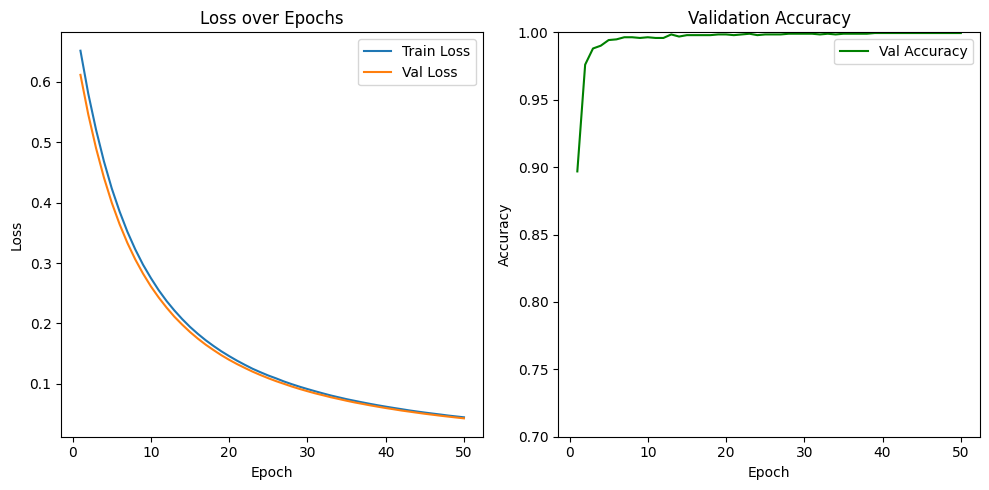

In [ ]:
import matplotlib.pyplot as plt

# =========================
# 3) Train the classifier
# =========================
@torch.no_grad()
def extract_features(x_batch):
    feats = frozen_encoder(x_batch)   # (B, D)
    return feats

def run_epoch(loader, train=False):
    if train: classifier.train()
    else:     classifier.eval()

    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x = x.to(device)   # (B, L, 2)
        y = y.to(device)

        with torch.no_grad():
            feats = extract_features(x)       # frozen encoder

        logits = classifier(feats)            # trainable head
        loss = criterion(logits, y)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * y.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total   += y.size(0)

    return total_loss/total, correct/total

# Track metrics for plotting
train_losses, val_losses, val_accs = [], [], []

EPOCHS = 50
for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    val_accs.append(va_acc)

    print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}")

# Final test
te_loss, te_acc = run_epoch(test_loader, train=False)
print(f"Test: loss {te_loss:.4f} acc {te_acc:.3f}")

# =========================
# Plotting
# =========================
epochs_range = range(1, EPOCHS+1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, val_accs, label="Val Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.ylim(0.7, 1.0)
plt.legend()

plt.tight_layout()
plt.show()


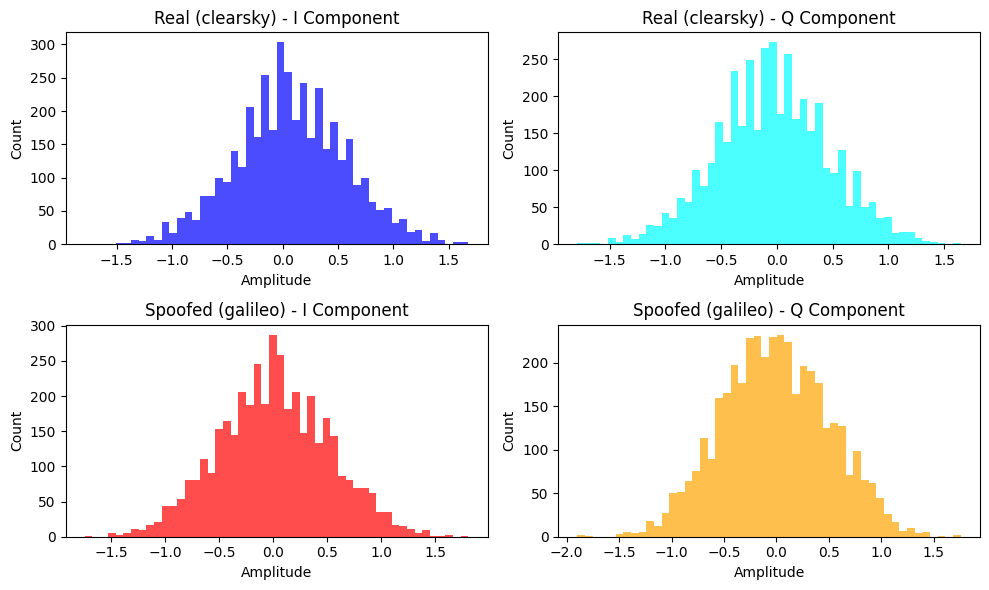

In [ ]:
import matplotlib.pyplot as plt

# Get one example window from each dataset
sample_real, _   = next(iter(DataLoader(ds_real, batch_size=1, shuffle=True)))
sample_spoof, _  = next(iter(DataLoader(ds_spoof, batch_size=1, shuffle=True)))

# Convert to numpy for plotting
real_i = sample_real[0,:,0].numpy()
real_q = sample_real[0,:,1].numpy()
spoof_i = sample_spoof[0,:,0].numpy()
spoof_q = sample_spoof[0,:,1].numpy()

# Plot histograms
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
bins = 50

axs[0,0].hist(real_i, bins=bins, color='blue', alpha=0.7)
axs[0,0].set_title("Real (clearsky) - I Component")
axs[0,1].hist(real_q, bins=bins, color='cyan', alpha=0.7)
axs[0,1].set_title("Real (clearsky) - Q Component")

axs[1,0].hist(spoof_i, bins=bins, color='red', alpha=0.7)
axs[1,0].set_title("Spoofed (galileo) - I Component")
axs[1,1].hist(spoof_q, bins=bins, color='orange', alpha=0.7)
axs[1,1].set_title("Spoofed (galileo) - Q Component")

for ax in axs.flat:
    ax.set_xlabel("Amplitude")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


/tmp/ipython-input-3492987881.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


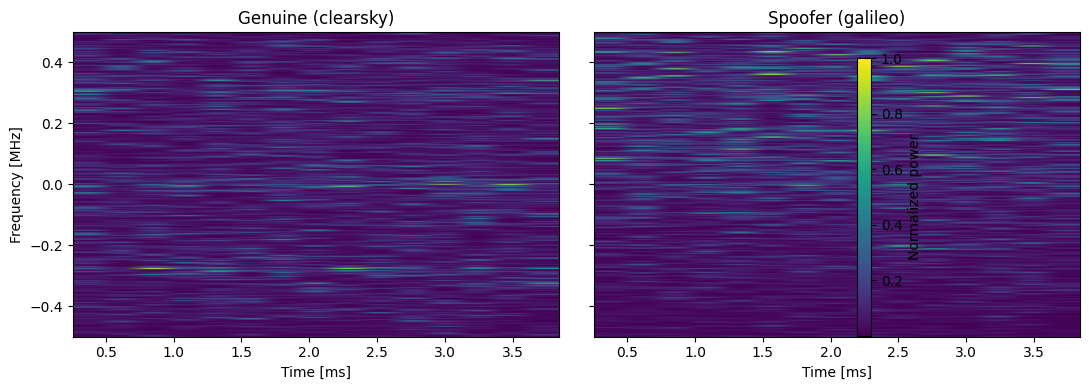

In [ ]:
# ---- STFT spectrograms: clearsky vs spoofed ---------------------------------
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from scipy.signal import stft, get_window

# 1) Grab one window from each dataset
real_win, _  = next(iter(DataLoader(ds_real,  batch_size=1, shuffle=True)))
spoof_win, _ = next(iter(DataLoader(ds_spoof, batch_size=1, shuffle=True)))

# Convert to complex baseband arrays (T,)
x_real  = real_win[0].numpy()
x_spoof = spoof_win[0].numpy()
cx_real  = x_real[:,0] + 1j * x_real[:,1]
cx_spoof = x_spoof[:,0] + 1j * x_spoof[:,1]

# 2) STFT params (tune fs_hz/nperseg for your sampling rate & desired resolution)
fs_hz   = 1_000_000          # <-- set to your actual sampling rate in Hz
nperseg = 512
noverlap = nperseg // 2
win = get_window('hann', nperseg)

def spectrogram_db(xc, fs):
    f, t, Z = stft(xc, fs=fs, window=win, nperseg=nperseg, noverlap=noverlap,
                   return_onesided=False, boundary=None, padded=False)
    P = np.abs(Z)**2
    P /= (P.max() + 1e-12)                  # normalize to [0,1]
    # Move DC to center frequency ordering
    f_shift = np.fft.fftshift(f)
    P_shift = np.fft.fftshift(P, axes=0)
    return t*1e3, f_shift/1e6, P_shift      # time [ms], freq [MHz], normalized power

t_ms_r, f_mhz_r, P_r = spectrogram_db(cx_real,  fs_hz)
t_ms_s, f_mhz_s, P_s = spectrogram_db(cx_spoof, fs_hz)

# 3) Plot side-by-side with a shared colorbar
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
im0 = axs[0].imshow(P_r, origin='lower', aspect='auto',
                    extent=[t_ms_r[0], t_ms_r[-1], f_mhz_r[0], f_mhz_r[-1]])
axs[0].set_title('Genuine (clearsky)')
axs[0].set_xlabel('Time [ms]')
axs[0].set_ylabel('Frequency [MHz]')

im1 = axs[1].imshow(P_s, origin='lower', aspect='auto',
                    extent=[t_ms_s[0], t_ms_s[-1], f_mhz_s[0], f_mhz_s[-1]])
axs[1].set_title('Spoofer (galileo)')
axs[1].set_xlabel('Time [ms]')

cbar = fig.colorbar(im1, ax=axs.ravel().tolist(), shrink=0.9)
cbar.set_label('Normalized power')

plt.tight_layout()
plt.show()


In [ ]:
# =========================
# Build spectrogram dataset
# =========================
import os, math, random
import numpy as np
import torch
from torch.utils.data import DataLoader
from scipy.signal import stft, get_window
from PIL import Image
from tqdm import tqdm

# --- STFT → image -------------------------------------------------------------
fs_hz   = 1_000_000             # TODO: set your actual sampling rate
nperseg = 512
noverlap = nperseg // 2
win = get_window('hann', nperseg)

def stft_to_img(x_complex):
    """
    x_complex: (T,) complex64
    returns: uint8 image array (H,W), 0..255
    """
    f, t, Z = stft(x_complex, fs=fs_hz, window=win, nperseg=nperseg,
                   noverlap=noverlap, return_onesided=False,
                   boundary=None, padded=False)
    P = np.abs(Z)**2

    # log scaling + dynamic range compression
    P_db = 10.0 * np.log10(P + 1e-12)
    P_db -= P_db.max()                          # max at 0 dB
    P_db = np.clip(P_db, -60.0, 0.0)            # keep last 60 dB
    P_norm = (P_db + 60.0) / 60.0               # [0,1]

    # center DC
    P_shift = np.fft.fftshift(P_norm, axes=0)
    img = (P_shift * 255.0).astype(np.uint8)    # (F, T)
    return img

def window_to_complex(win_tensor):
    """(L,2) -> complex (L,)"""
    x = win_tensor.numpy()
    return x[:,0] + 1j*x[:,1]

# --- Output layout ------------------------------------------------------------
root = "/content/spectro_dataset"
splits = ["train", "val", "test"]
classes = ["real", "spoof"]
for sp in splits:
    for c in classes:
        os.makedirs(os.path.join(root, sp, c), exist_ok=True)

# --- Create indices & split (balanced) ---------------------------------------
n = min(len(ds_real), len(ds_spoof))
idx_all = list(range(n))
random.seed(42)
random.shuffle(idx_all)

n_train = int(0.80 * n)
n_val   = int(0.10 * n)
train_idx = idx_all[:n_train]
val_idx   = idx_all[n_train:n_train+n_val]
test_idx  = idx_all[n_train+n_val:]

def save_split(ds_real, ds_spoof, indices, split_name):
    real_loader  = DataLoader(torch.utils.data.Subset(ds_real, indices),
                              batch_size=1, shuffle=False)
    spoof_loader = DataLoader(torch.utils.data.Subset(ds_spoof, indices),
                              batch_size=1, shuffle=False)

    # Save real
    pbar = tqdm(real_loader, desc=f"{split_name} real")
    for i, (x, _) in enumerate(pbar):
        xc = window_to_complex(x[0])
        img = stft_to_img(xc)
        Image.fromarray(img).save(os.path.join(root, split_name, "real", f"r_{i:06d}.png"))

    # Save spoof
    pbar = tqdm(spoof_loader, desc=f"{split_name} spoof")
    for i, (x, _) in enumerate(pbar):
        xc = window_to_complex(x[0])
        img = stft_to_img(xc)
        Image.fromarray(img).save(os.path.join(root, split_name, "spoof", f"s_{i:06d}.png"))

save_split(ds_real, ds_spoof, train_idx, "train")
save_split(ds_real, ds_spoof, val_idx,   "val")
save_split(ds_real, ds_spoof, test_idx,  "test")

print("Done. Dataset at:", root)


test spoof: 100%|██████████| 641/641 [00:00<00:00, 691.45it/s]

Done. Dataset at: /content/spectro_dataset


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Grayscale spectrograms → 1 channel
tfm = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),                      # [0,1]
    transforms.Normalize(mean=[0.5], std=[0.5]) # optional
])

train_ds = datasets.ImageFolder(os.path.join(root, "train"), transform=tfm)
val_ds   = datasets.ImageFolder(os.path.join(root, "val"),   transform=tfm)
test_ds  = datasets.ImageFolder(os.path.join(root, "test"),  transform=tfm)

train_loader_img = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_img   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_img  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(train_ds.classes)  # ['real', 'spoof']
print(len(train_ds), len(val_ds), len(test_ds))


['real', 'spoof']
10238 1278 1282


100%|██████████| 20/20 [00:00<00:00, 27.60it/s]


Epoch 01 | train loss 0.2087 | val loss 0.1838 | val acc 0.961
  ↳ Saved best: /content/shallowcnn6_best.pt (val acc 0.961)


100%|██████████| 20/20 [00:00<00:00, 26.75it/s]


Epoch 02 | train loss 0.0681 | val loss 0.0920 | val acc 0.983
  ↳ Saved best: /content/shallowcnn6_best.pt (val acc 0.983)


100%|██████████| 20/20 [00:00<00:00, 25.69it/s]


...

Epoch 19 | train loss 0.0028 | val loss 0.0078 | val acc 0.998


100%|██████████| 20/20 [00:00<00:00, 27.86it/s]


Epoch 20 | train loss 0.0069 | val loss 0.0030 | val acc 0.998


100%|██████████| 21/21 [00:00<00:00, 28.16it/s]


TEST — loss: 0.0095 | acc: 1.000


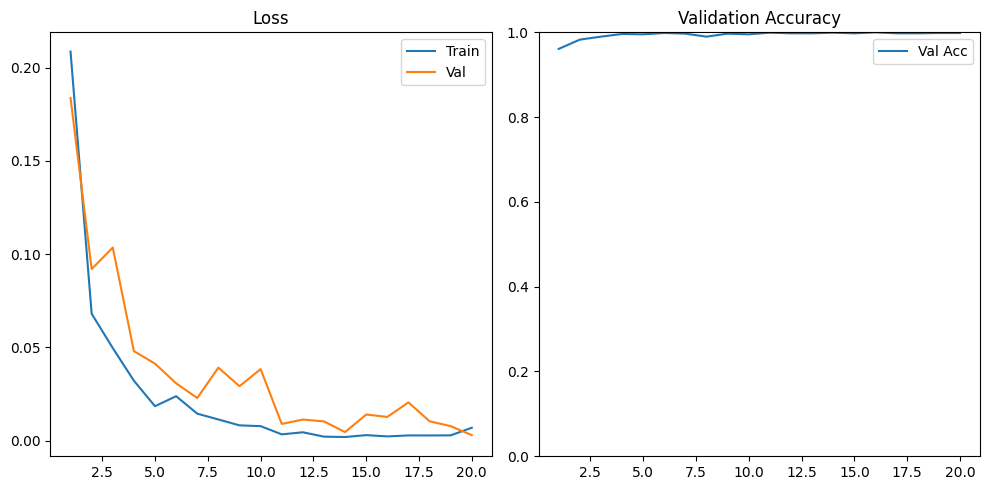

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

class ShallowCNN6(nn.Module):
    """
    Input: (B, 1, H, W) spectrograms
    Conv layers: 6 total
    """
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # 1
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            # 2
            nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(0.1),

            # 3
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            # 4
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(0.1),

            # 5
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            # 6
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.head(x)

model = ShallowCNN6(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Use the loaders you already created for the spectrogram ImageFolder
train_loader = train_loader_img
val_loader   = val_loader_img
test_loader  = test_loader_img

def run_epoch(loader, train=False):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    for x, y in tqdm(loader, disable=False):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * y.size(0)
        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total   += y.size(0)
    return total_loss/total, correct/total

EPOCHS = 20
train_losses, val_losses, val_accs = [], [], []
best_acc, best_path = 0.0, "/content/shallowcnn6_best.pt"

for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    train_losses.append(tr_loss); val_losses.append(va_loss); val_accs.append(va_acc)
    print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} | val loss {va_loss:.4f} | val acc {va_acc:.3f}")

    if va_acc > best_acc:
        best_acc = va_acc
        torch.save({"model": model.state_dict()}, best_path)
        print(f"  ↳ Saved best: {best_path} (val acc {best_acc:.3f})")

# Test
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model"])
test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"TEST — loss: {test_loss:.4f} | acc: {test_acc:.3f}")

# Optional: simple plots
import matplotlib.pyplot as plt
epochs = range(1, EPOCHS+1)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.plot(epochs, train_losses, label="Train"); plt.plot(epochs, val_losses, label="Val"); plt.legend(); plt.title("Loss")
plt.subplot(1,2,2); plt.plot(epochs, val_accs, label="Val Acc"); plt.ylim(0,1); plt.legend(); plt.title("Validation Accuracy")
plt.tight_layout(); plt.show()


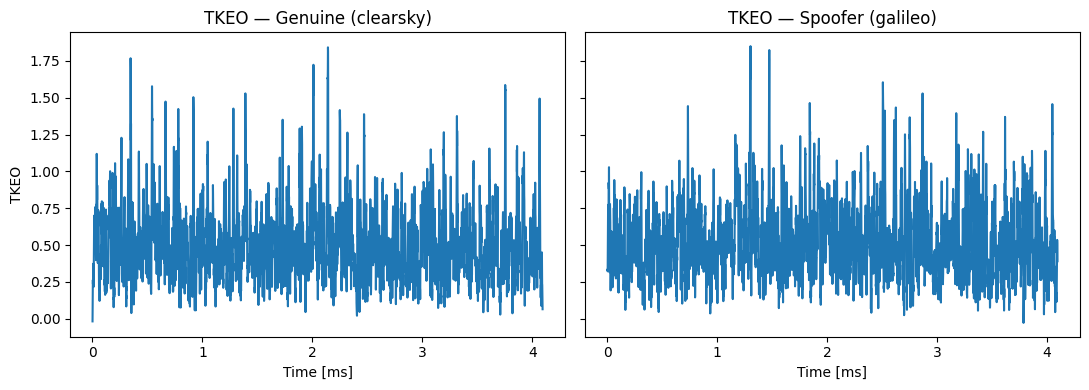

In [ ]:
# --- TKEO for complex baseband and plots (clearsky vs spoofed) ----------------
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Set your sampling rate in Hz (used only for the x-axis in ms)
fs_hz = 1_000_000  # TODO: set to your actual sampling rate

def to_complex(win_tensor):
    """(L,2) -> complex (L,)"""
    x = win_tensor.numpy()
    return x[:,0] + 1j*x[:,1]

def tkeo_complex(r: np.ndarray) -> np.ndarray:
    """
    T_TKEO(n) = |r(n)|^2 - 0.5*( r*(n+1)r(n-1) + r(n+1)r*(n-1) )
               = |r(n)|^2 - Re{ r*(n+1) r(n-1) }
    Returns array of length len(r)-2 (valid indices).
    """
    r_m1 = r[:-2]
    r_0  = r[1:-1]
    r_p1 = r[2:]
    return np.abs(r_0)**2 - np.real(np.conj(r_p1) * r_m1)

# Grab one random window from each dataset
real_win, _  = next(iter(DataLoader(ds_real,  batch_size=1, shuffle=True)))
spoof_win, _ = next(iter(DataLoader(ds_spoof, batch_size=1, shuffle=True)))

# Convert to complex and compute TKEO
r_real  = to_complex(real_win[0])
r_spoof = to_complex(spoof_win[0])

tkeo_real  = tkeo_complex(r_real)
tkeo_spoof = tkeo_complex(r_spoof)

# Time axis in milliseconds for the "valid" indices (1 .. L-2)
L = r_real.shape[0]
t_ms = (np.arange(1, L-1) / fs_hz) * 1e3

# Optional: light smoothing for readability (comment out if not needed)
def smooth(x, k=7):
    if k <= 1: return x
    k = int(k)
    w = np.ones(k) / k
    return np.convolve(x, w, mode='same')

tkeo_real_s  = smooth(tkeo_real,  k=7)
tkeo_spoof_s = smooth(tkeo_spoof, k=7)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axs[0].plot(t_ms, tkeo_real_s)
axs[0].set_title("TKEO — Genuine (clearsky)")
axs[0].set_xlabel("Time [ms]")
axs[0].set_ylabel("TKEO")

axs[1].plot(t_ms, tkeo_spoof_s)
axs[1].set_title("TKEO — Spoofer (galileo)")
axs[1].set_xlabel("Time [ms]")

plt.tight_layout()
plt.show()


Genuine  window: mean EVM = 2152.13%  | fitted f0 ≈ -244.1 Hz
Spoofer window: mean EVM = 3110.31%  | fitted f0 ≈ 306640.6 Hz


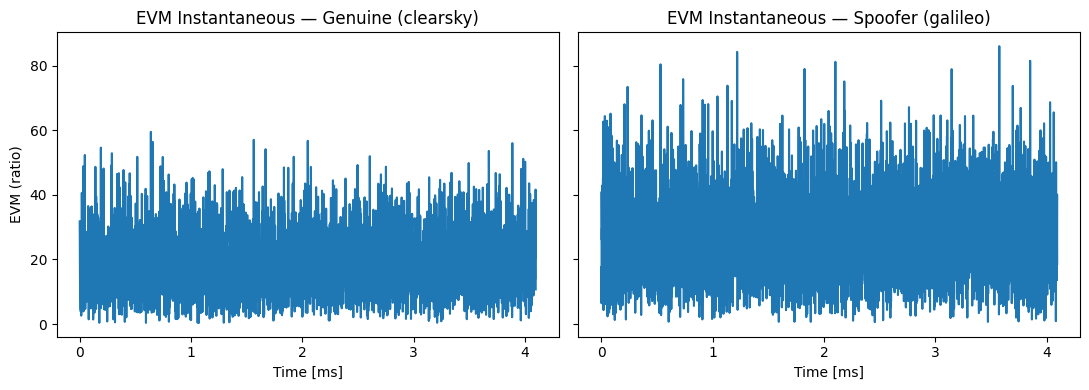

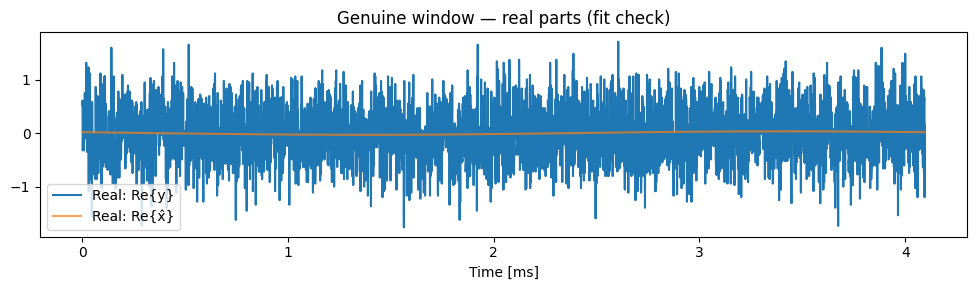

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ---- helpers -----------------------------------------------------------------
fs_hz = 1_000_000  # TODO: set your actual sampling rate

def to_complex(win_tensor):
    x = win_tensor.numpy()
    return x[:,0] + 1j*x[:,1]

def dominant_tone_fit(y, fs):
    """
    Estimate a single complex exponential s[n] = exp(j*2πf0*n/fs) that best fits y.
    Returns xhat (complex), f0 (Hz).
    """
    N = len(y)
    # 1) coarse frequency by FFT peak
    Y = np.fft.fft(y * np.hanning(N))
    k0 = np.argmax(np.abs(Y))
    # map bin -> frequency in Hz in [-fs/2, fs/2)
    f_bins = np.fft.fftfreq(N, d=1/fs)
    f0 = f_bins[k0]

    # 2) build tone and LS amplitude/phase
    n = np.arange(N)
    s = np.exp(1j * 2*np.pi * f0 * n / fs)
    alpha = np.vdot(s, y) / np.vdot(s, s)     # complex LS gain
    xhat = alpha * s
    return xhat, float(f0)

def evm(y, xhat, eps=1e-12):
    e = y - xhat
    evm_scalar = np.linalg.norm(e) / (np.linalg.norm(xhat) + eps)
    evm_inst   = np.abs(e) / (np.abs(xhat) + eps)
    return evm_scalar, evm_inst

# ---- get a random window from each class -------------------------------------
real_win, _  = next(iter(DataLoader(ds_real,  batch_size=1, shuffle=True)))
spoof_win, _ = next(iter(DataLoader(ds_spoof, batch_size=1, shuffle=True)))
y_real  = to_complex(real_win[0])
y_spoof = to_complex(spoof_win[0])

# ---- fit ideal references and compute EVM ------------------------------------
xhat_r, f0_r = dominant_tone_fit(y_real,  fs_hz)
xhat_s, f0_s = dominant_tone_fit(y_spoof, fs_hz)

evm_r, evm_inst_r = evm(y_real,  xhat_r)
evm_s, evm_inst_s = evm(y_spoof, xhat_s)

# time axis (ms)
t_ms_r = np.arange(len(y_real))  / fs_hz * 1e3
t_ms_s = np.arange(len(y_spoof)) / fs_hz * 1e3

print(f"Genuine  window: mean EVM = {100*evm_r:.2f}%  | fitted f0 ≈ {f0_r:.1f} Hz")
print(f"Spoofer window: mean EVM = {100*evm_s:.2f}%  | fitted f0 ≈ {f0_s:.1f} Hz")

# ---- plot per-sample (instantaneous) EVM -------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(11,4), sharey=True)
axs[0].plot(t_ms_r, evm_inst_r)
axs[0].set_title("EVM Instantaneous — Genuine (clearsky)")
axs[0].set_xlabel("Time [ms]"); axs[0].set_ylabel("EVM (ratio)")

axs[1].plot(t_ms_s, evm_inst_s)
axs[1].set_title("EVM Instantaneous — Spoofer (galileo)")
axs[1].set_xlabel("Time [ms]")

plt.tight_layout(); plt.show()

# ---- (optional) overlay y and fitted x̂ to see the mismatch -------------------
plt.figure(figsize=(10,3))
plt.plot(t_ms_r, np.real(y_real),  label="Real: Re{y}")
plt.plot(t_ms_r, np.real(xhat_r), label="Real: Re{x̂}", alpha=0.7)
plt.title("Genuine window — real parts (fit check)"); plt.xlabel("Time [ms]"); plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
## Jepa

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ---------------------------
# 1. Generate Synthetic Dataset
# ---------------------------
def generate_signal(num_samples=2000, num_sin=30, noise_std=0.1):
    x = np.linspace(0, 1, num_samples)
    signal = np.zeros_like(x)
    for _ in range(num_sin):
        freq = np.random.uniform(2, 300)
        phase = np.random.uniform(0, np.pi)
        amp = np.random.uniform(0.5, 1.0)
        signal += amp * np.cos(2 * np.pi * freq * x + phase)
    signal += np.random.normal(0, noise_std, size=x.shape)
    return signal.astype(np.float32)

# ---------------------------
# 2. Spectral Masking (Non-overlapping)
# ---------------------------
def spectral_mask(signal, mask_width=300):
    fft = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(fft))

    min_bin = mask_width
    max_bin = len(fft)//2 - mask_width

    # Pick target window
    target_center = np.random.randint(min_bin, max_bin)
    target_low = target_center - mask_width
    target_high = target_center + mask_width

    # Pick context masked window far from target
    while True:
        context_center = np.random.randint(min_bin, max_bin)
        if abs(context_center - target_center) > 2 * mask_width:
            break
    context_low = context_center - mask_width
    context_high = context_center + mask_width

    # Build context input (mask context band)
    fft_context = fft.copy()
    fft_context[context_low:context_high] = 0
    x_context = np.fft.ifft(fft_context).real.astype(np.float32)

    # Build target input (isolate target band only)
    fft_target = np.zeros_like(fft)
    fft_target[target_low:target_high] = fft[target_low:target_high]
    x_target = np.fft.ifft(fft_target).real.astype(np.float32)

    return x_context, x_target, freqs[target_center]

# ---------------------------
# 3. JEPA Modules
# ---------------------------
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3), nn.ReLU(),
            nn.Conv1d(32, 64, 7, padding=3), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

class Predictor(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + 1, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
    def forward(self, z_context, freq):
        freq = freq.unsqueeze(1)
        z = torch.cat([z_context, freq], dim=1)
        return self.net(z)

# ---------------------------
# 4. Training Loop
# ---------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
context_encoder = Encoder().to(device)
target_encoder = Encoder().to(device)
predictor = Predictor().to(device)

optimizer = optim.Adam(
    list(context_encoder.parameters()) +
    list(target_encoder.parameters()) +
    list(predictor.parameters()), lr=3e-4
)
loss_fn = nn.MSELoss()

print("🚀 Training JEPA with spectral masking...")

for step in range(1000):
    # Generate data
    signal = generate_signal()
    x_context, x_target, freq = spectral_mask(signal)

    # Convert to tensors
    x_context = torch.tensor(x_context).unsqueeze(0).unsqueeze(0).to(device)
    x_target = torch.tensor(x_target).unsqueeze(0).unsqueeze(0).to(device)
    freq = torch.tensor([freq]).float().to(device)

    # Forward pass
    z_context = context_encoder(x_context)
    z_target = target_encoder(x_target).detach()  # stop gradient to target encoder
    z_pred = predictor(z_context, freq)

    # Loss
    loss = loss_fn(z_pred, z_target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 100 == 0:
        print(f"Step {step} | Loss: {loss.item():.4f}")

print("✅ Training complete!")


🚀 Training JEPA with spectral masking...


KeyboardInterrupt: 

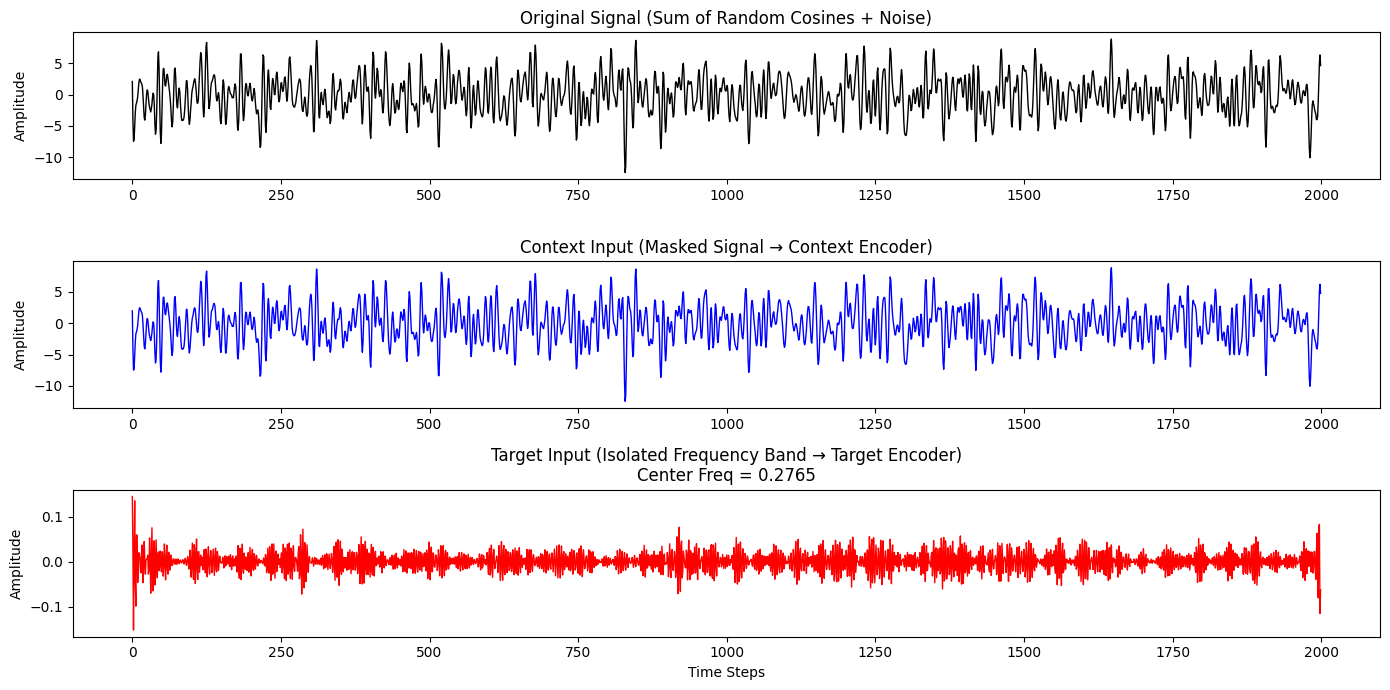

In [ ]:
import matplotlib.pyplot as plt

# Generate a fresh signal sample for visualization
signal = generate_signal()
x_context, x_target, freq = spectral_mask(signal)

plt.figure(figsize=(14, 7))

# ---- 1. Original Signal ----
plt.subplot(3, 1, 1)
plt.plot(signal, color='black', linewidth=1)
plt.title("Original Signal (Sum of Random Cosines + Noise)")
plt.ylabel("Amplitude")

# ---- 2. Context Input ----
plt.subplot(3, 1, 2)
plt.plot(x_context, color='blue', linewidth=1)
plt.title("Context Input (Masked Signal → Context Encoder)")
plt.ylabel("Amplitude")

# ---- 3. Target Input ----
plt.subplot(3, 1, 3)
plt.plot(x_target, color='red', linewidth=1)
plt.title(f"Target Input (Isolated Frequency Band → Target Encoder)\nCenter Freq = {freq:.4f}")
plt.ylabel("Amplitude")
plt.xlabel("Time Steps")

plt.tight_layout()
plt.show()


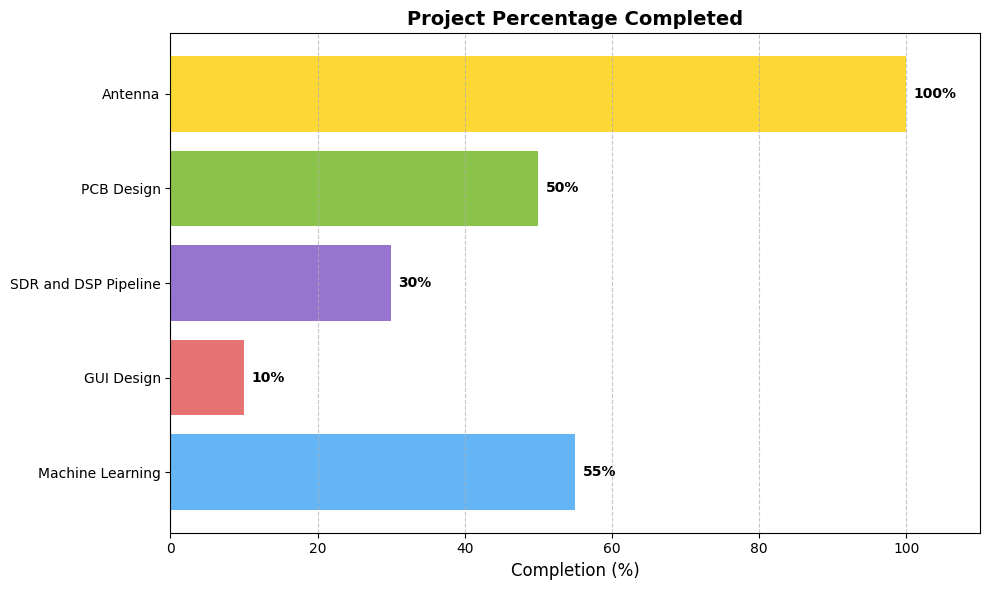

In [ ]:
import matplotlib.pyplot as plt

# 1. Data from your image
tasks = [
    "Antenna",
    "PCB Design",
    "SDR and DSP Pipeline",
    "GUI Design",
    "Machine Learning"
]

progress = [100, 50, 30, 10, 55]

# 2. Colors matching your image
# Yellow, Green, Purple, Red/Salmon, Blue
colors = ['#FDD835', '#8BC34A', '#9575CD', '#E57373', '#64B5F6']

# 3. Create the Horizontal Bar Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(tasks, progress, color=colors)

# 4. Styling
plt.title("Project Percentage Completed", fontsize=14, fontweight='bold')
plt.xlabel("Completion (%)", fontsize=12)
plt.xlim(0, 110)  # Set limit slightly above 100 for space
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 5. Add percentage labels to the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,       # x-position (slightly to the right of the bar)
        bar.get_y() + bar.get_height()/2, # y-position (center of bar)
        f'{width}%',     # Label text
        va='center',     # Vertical alignment
        fontweight='bold'
    )

# 6. Invert y-axis so the first item ('Antenna') is at the top
plt.gca().invert_yaxis()

# 7. Show the plot
plt.tight_layout()
plt.show()